In [ ]:
import sys

assert sys.version_info >= (3, 7)

from packaging import version
import sklearn

assert version.parse(sklearn.__version__) >= version.parse("1.0.1")

import matplotlib.pyplot as plt

plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

from pathlib import Path

IMAGES_PATH = Path() / "images" / "training_linear_models"
IMAGES_PATH.mkdir(parents=True, exist_ok=True)

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = IMAGES_PATH / f"{fig_id}.{fig_extension}"
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

선형 회귀

In [ ]:
import numpy as np

# 코드의 실행 결과 재현을 위해 난수 시드 고정
np.random.seed(42)

m = 100  # 샘플의 개수
# 균등 분포, [0.0, 1.0) 실수 반환
X = 2 * np.random.rand(m, 1) # 열 벡터
# 표준 정규 분포, -무한대에서 무한대의 모든 실수를 반환하나, 정규 분표 규칙 (68-95-99.7)을 따른다. 노이즈 추가
y = 3 * X + 4 + np.random.randn(m, 1) # 열 벡터

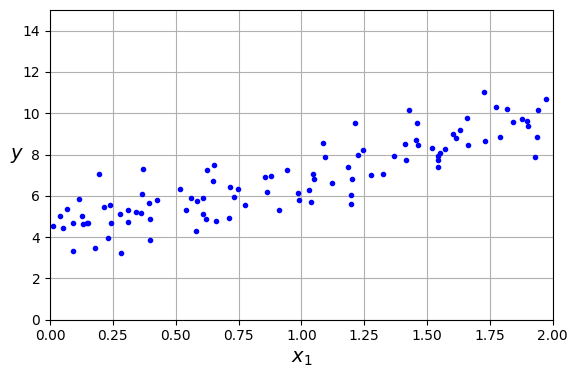

In [ ]:
# x축 = feature, y축 = label

import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.plot(X, y, "b.")
plt.xlabel("$x_1$")
plt.ylabel("$y$", rotation=0)
plt.axis([0, 2, 0, 15])
plt.grid()
save_fig("generated_data_plot")
plt.show()

In [ ]:
# 닫힌 형태의 방정식에서, 비용 함수를 최소화하는 파라미터를 즉시 찾을 수 있는 정규 방정식 사용

# 데이터 행렬의 맨 앞에 1로만 채워진 열을 추가
# -> 선형 회귀 모델의 가설 y = ax + b에서, 편향 b에 대한 연산 용이하게 처리
from sklearn.preprocessing import add_dummy_feature

X_b = add_dummy_feature(X)  # 각 샘플에 x0 = 1을 추가
theta_best = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ y # 정규 방정식을 통해 최적의 파라미터 계산

In [ ]:
theta_best

array([[4.21509616],
       [2.77011339]])

**y = 3x + 4 + 가우스 노이즈** 에 대한 정규 방정식의 해

array([[4.21509616],
       [2.77011339]])

실제: Θ1 = 3, Θ2 = 4

예측: Θ1 = 4.215, Θ2= 2.770

In [ ]:
X_new = np.array([[0], [2]]) # 2, 1

X_new_b = add_dummy_feature(X_new)

y_predict = X_new_b @ theta_best # x = 0, x = 2에서의 예측값 계산

y_predict

array([[4.21509616],
       [9.75532293]])

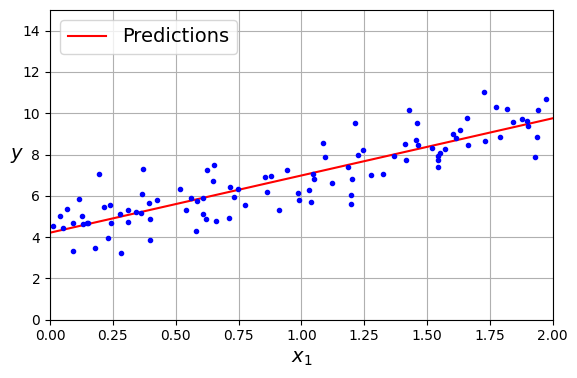

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))  # 추가 코드
plt.plot(X_new, y_predict, "r-", label="Predictions")
plt.plot(X, y, "b.")

plt.xlabel("$x_1$")
plt.ylabel("$y$", rotation=0)
plt.axis([0, 2, 0, 15])
plt.grid()
plt.legend(loc="upper left")
save_fig("linear_model_predictions_plot")

plt.show()

In [ ]:
# 사이킷런의 선형 회귀 모델 사용
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
lin_reg.fit(X, y)

lin_reg.intercept_, lin_reg.coef_ # 가중치, 편향
# (array([4.21509616]), array([[2.77011339]]))

lin_reg.predict(X_new)
# array([[4.21509616],
#        [9.75532293]])

array([[4.21509616],
       [9.75532293]])

In [ ]:
# 이전 정규방정식 풀이에서, 행렬식이 0이 아닌 정사각행렬이 아니라면 역행렬을 구할 수 없기 때문에,
# 특이값 분해를 통해 유사역행렬을 구하여 일반적인 상황에서도 정규방정식으로 풀 수 있다.

theta_best_svd, residuals, rank, s = np.linalg.lstsq(X_b, y, rcond=1e-6)
theta_best_svd

array([[4.21509616],
       [2.77011339]])

정규 방정식은 (n + 1) * (n + 1) 크기의 X.T @ X 의 역행렬을 계산(n = 특성의 개수) -> 시간 복잡도는 O(n2.4) ~ O(n3), 계산 시간이 상당히 걸린다.

LinearRegression 클래스의 특잇값 분해, SVD 방식은 약 O(n2)이다.

경사 하강법

In [16]:
# 각 모델 파라미터에 대해 비용 함수의 기울기를 계산, 즉 각 파라미터에 대해 편도함수를 구한다.

eta = 0.5  # 학습률
n_epochs = 1000  # 에포크
m = len(X_b)  # 샘플 개수

np.random.seed(42)
theta = np.random.randn(2, 1)  # 임의의 파라미터

for epoch in range(n_epochs):
  gradients = 2/m * X_b.T @ (X_b @ theta - y)
  theta = theta - eta * gradients

# 졍규 방정식으로 찾은 결과와 같다.
theta

array([[-7.05138935e+27],
       [-7.98621001e+27]])

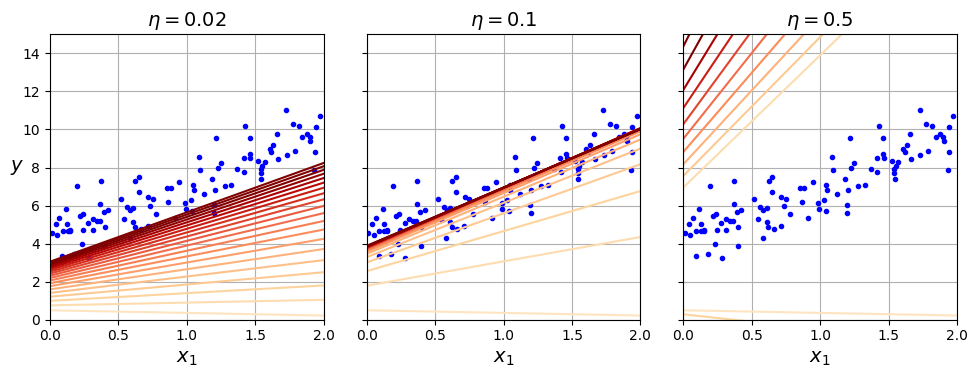

In [18]:
import matplotlib as mpl

def plot_gradient_descent(theta, eta):
    m = len(X_b)
    plt.plot(X, y, "b.")
    n_epochs = 1000
    n_shown = 20
    theta_path = []
    for epoch in range(n_epochs):
        if epoch < n_shown:
            y_predict = X_new_b @ theta
            color = mpl.colors.rgb2hex(plt.cm.OrRd(epoch / n_shown + 0.15))
            plt.plot(X_new, y_predict, linestyle="solid", color=color)
        gradients = 2 / m * X_b.T @ (X_b @ theta - y)
        theta = theta - eta * gradients
        theta_path.append(theta)
    plt.xlabel("$x_1$")
    plt.axis([0, 2, 0, 15])
    plt.grid()
    plt.title(fr"$\eta = {eta}$")
    return theta_path

np.random.seed(42)
theta = np.random.randn(2, 1)  # 랜덤 초기화

plt.figure(figsize=(10, 4))
plt.subplot(131)
plot_gradient_descent(theta, eta=0.02)
plt.ylabel("$y$", rotation=0)
plt.subplot(132)
theta_path_bgd = plot_gradient_descent(theta, eta=0.1)
plt.gca().axes.yaxis.set_ticklabels([])
plt.subplot(133)
plt.gca().axes.yaxis.set_ticklabels([])
plot_gradient_descent(theta, eta=0.5)
save_fig("gradient_descent_plot")
plt.show()

# 하이퍼 파라미터인 학습률을 다르게 하여 학습할 수 있는데, 학습률을 0.02로 매우 작게 설정한 경우
# 주어진 에포크 내 최적점에 도달하지 못함을 보이며 학습률을 0.5로 매우 크게 설정한 경우
# 스텝마다 최적점에서 멀어쳐 결국 발산하는 모습을 보인다. 따라서 적절한 학습률을 찾기 위해 그리드 서치라는 기법을 사용한다.

# 반복 횟수인 에포크 또한 하이퍼 파라미터로 너무 작다면 최적점에 도달하기 전 학습이 종료되며
# 너무 크다면 파라미터가 최적점에 도달했음에도 학습이 계속해서 이루어지는 점이 있다.
# 이는 반복 횟수를 매우 크게 지정한 후 기울기 벡터의 노름이 작아지면, 즉 최적점에 허용 오차만큼 다가가면 학습을 중지할 수 있다.

In [21]:
# 위와 같은 배치 경사 하강법은 매 스텝마다 전체 훈련 세트를 사용하여 기울기를 계산하므로, 훈련 세트가 매우 커지만 학습 비용이 커진다.
# 이 때, 확률적 경사 하강법을 통해 하나의 샘플을 랜덤으로 선택한 후, 그 샘플에 대한 기울기를 계산하여 학습을 진행할 수 있다.
# 이는 매 스텝에서 하나의 샘플만 메모리를 사용하므로 빠르다는 장점이 있지만, 학습 경로가 불안정하며 최적점에 근접하더라도 안착하지 못할 가능성이 있다.
# 또한 지역 최솟값 문제의 관점에서, 불규칙한 학습 경로로 인해 배치 경사 하강법에 비해 전역 최솟값을 찾을 가능성이 높다는 점이 있다.

# 이러한 특징은 빠른 학습과 지역 최솟값 문제를 벗어날 수도 있다는 점에서 유리하지만, 전역 최솟값에 수렴하지 않을 수 있다는 점에
# 고정된 학습률이 아닌 매 반복마다 학습률을 결정하는 학습률 스케쥴러를 통해 점진적으로 학습률을 감소시킬 수 있다.

n_epochs = 50
t0, t1 = 5, 50  # 학습 스케줄 하이퍼 파라미터

def learning_schedule(t):
    return t0 / (t + t1)

np.random.seed(42)
theta = np.random.randn(2, 1)  # 랜덤 초기화

for epoch in range(n_epochs):
    for iteration in range(m):
        random_index = np.random.randint(m)
        xi = X_b[random_index : random_index + 1]
        yi = y[random_index : random_index + 1]
        gradients = 2 * xi.T @ (xi @ theta - yi)
        eta = learning_schedule(epoch * m + iteration)
        theta = theta - eta * gradients

theta

array([[4.21076011],
       [2.74856079]])

In [25]:
# 사이킷런에서의 확률적 경사 하강법, SGD
from sklearn.linear_model import SGDRegressor

sgd_reg = SGDRegressor(max_iter=1000, tol=1e-5, penalty=None, eta0=0.01,
                       n_iter_no_change=100, random_state=42)

sgd_reg.fit(X, y.ravel())

sgd_reg.intercept_, sgd_reg.coef_

(array([4.21278812]), array([2.77270267]))

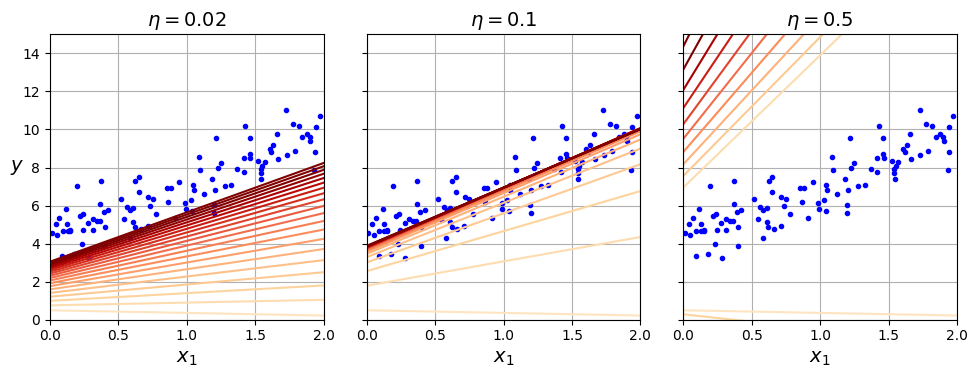

In [29]:
# 추가 코드 - 그림 4-8을 생성하고 저장합니다.

import matplotlib as mpl

def plot_gradient_descent(theta, eta):
    m = len(X_b)
    plt.plot(X, y, "b.")
    n_epochs = 1000
    n_shown = 20
    theta_path = []
    for epoch in range(n_epochs):
        if epoch < n_shown:
            y_predict = X_new_b @ theta
            color = mpl.colors.rgb2hex(plt.cm.OrRd(epoch / n_shown + 0.15))
            plt.plot(X_new, y_predict, linestyle="solid", color=color)
        gradients = 2 / m * X_b.T @ (X_b @ theta - y)
        theta = theta - eta * gradients
        theta_path.append(theta)
    plt.xlabel("$x_1$")
    plt.axis([0, 2, 0, 15])
    plt.grid()
    plt.title(fr"$\eta = {eta}$")
    return theta_path

np.random.seed(42)
theta = np.random.randn(2, 1)  # 랜덤 초기화

plt.figure(figsize=(10, 4))
plt.subplot(131)
plot_gradient_descent(theta, eta=0.02)
plt.ylabel("$y$", rotation=0)
plt.subplot(132)
theta_path_bgd = plot_gradient_descent(theta, eta=0.1)
plt.gca().axes.yaxis.set_ticklabels([])
plt.subplot(133)
plt.gca().axes.yaxis.set_ticklabels([])
plot_gradient_descent(theta, eta=0.5)
save_fig("gradient_descent_plot")
plt.show()

In [32]:
# 배치와 확률적 경사 하강법에 이어 임의의 작은 샘플 세트에 대해 기울기를 계산하는 미니배치 경사 하강법이 존재한다.
# 미니배치 크기에 따라 배치 또는 확률적 경사 하강법의 특성과 유사해지며, 이 경우에도 적절한 학습 스케쥴을 적용할 수 있다.